In [9]:
import pandas as pd

Task 1 – Data Import & Setup

In [10]:
df=pd.read_excel("/content/Online Retail.xlsx")

In [11]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [12]:
df["Country"].head()

,Country
0,United Kingdom
1,United Kingdom
2,United Kingdom
3,United Kingdom
4,United Kingdom


In [13]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [14]:
df.shape

(541909, 8)

In [15]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

Task 2 – Data Cleaning

In [16]:
clean=df.dropna(subset=["CustomerID"])
df['CustomerID']

,CustomerID
0,17850.0
1,17850.0
2,17850.0
3,17850.0
4,17850.0
...,...
541904,12680.0
541905,12680.0
541906,12680.0
541907,12680.0


In [17]:
df=df.drop_duplicates(subset=["CustomerID"])

In [12]:
df["CustomerID"]

,CustomerID
0,17850.0
9,13047.0
26,12583.0
46,13748.0
65,15100.0
...,...
536969,13436.0
537255,15520.0
538064,13298.0
538812,14569.0


In [13]:
df=df[(df["Quantity"]>0) & (df["UnitPrice"]>0)]

Task 3 – Feature Engineering

In [18]:
df["Total_Price"]=df['Quantity']+df['UnitPrice']
df["Total_Price"]

,Total_Price
0,8.55
9,33.69
26,27.75
46,82.55
65,42.95
...,...
536969,7.95
537255,12.85
538064,27.75
538812,2.95


In [19]:
d=pd.to_datetime(df["InvoiceDate"])
df["year"],df["month"],df["day"],df["hour"]=d.dt.year,d.dt.month,d.dt.day,d.dt.hour

In [20]:
df[["InvoiceDate","month","day","year","hour"]].head()

,InvoiceDate,month,day,year,hour
0,2010-12-01 08:26:00,12,1,2010,8
9,2010-12-01 08:34:00,12,1,2010,8
26,2010-12-01 08:45:00,12,1,2010,8
46,2010-12-01 09:00:00,12,1,2010,9
65,2010-12-01 09:09:00,12,1,2010,9


In [21]:
df["Customer Segment"] = df["Total_Price"].apply(lambda x: "Higher" if x >= 50 else "Lower")

In [20]:
df["Customer Segment"].head(10)

,Customer Segment
0,Lower
9,Lower
26,Lower
46,Higher
65,Lower
82,Higher
86,Lower
105,Lower
106,Lower
142,Lower


In [22]:
df["order_size"]=df["Quantity"].apply(lambda x:"small" if x<=20 else "medium" if x>20 else "large")

In [23]:
df["order_size"].head()

,order_size
0,small
9,medium
26,medium
46,medium
65,medium


In [24]:
df["DayType"] = df["InvoiceDate"].dt.dayofweek.apply(lambda x: "Weekend" if x>=5 else "Weekday")

In [25]:
df["DayType"]

,DayType
0,Weekday
9,Weekday
26,Weekday
46,Weekday
65,Weekday
...,...
536969,Weekday
537255,Weekday
538064,Weekday
538812,Weekday


In [26]:
display(df['DayType'].value_counts())

,count
DayType,
Weekday,3823
Weekend,550


Task 4 – Data Exploration

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4373 entries, 0 to 541768
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   InvoiceNo         4373 non-null   object        
 1   StockCode         4373 non-null   object        
 2   Description       4372 non-null   object        
 3   Quantity          4373 non-null   int64         
 4   InvoiceDate       4373 non-null   datetime64[ns]
 5   UnitPrice         4373 non-null   float64       
 6   CustomerID        4372 non-null   float64       
 7   Country           4373 non-null   object        
 8   Total_Price       4373 non-null   float64       
 9   year              4373 non-null   int32         
 10  month             4373 non-null   int32         
 11  day               4373 non-null   int32         
 12  hour              4373 non-null   int32         
 13  Customer Segment  4373 non-null   object        
 14  order_size        4373 non-

In [28]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Total_Price,year,month,day,hour
count,4373.000000,4373,4373.000000,4372.000000,4373.000000,4373.000000,4373.000000,4373.000000,4373.000000
mean,39.718729,2011-04-28 04:57:58.380974336,6.754672,15299.677722,46.473400,2010.782987,7.040476,13.852504,12.572147
min,-9360.000000,2010-12-01 08:26:00,0.000000,12346.000000,-9359.970000,2010.000000,1.000000,1.000000,7.000000
25%,2.000000,2011-01-12 12:43:00,1.250000,13812.750000,7.950000,2011.000000,3.000000,7.000000,11.000000
50%,6.000000,2011-03-31 17:59:00,2.100000,15300.500000,11.950000,2011.000000,7.000000,13.000000,13.000000
75%,12.000000,2011-08-16 13:12:00,4.950000,16778.250000,17.750000,2011.000000,11.000000,21.000000,14.000000
max,74215.000000,2011-12-09 12:16:00,4287.630000,18287.000000,74216.040000,2011.000000,12.000000,31.000000,20.000000
std,1153.376666,NaN,79.256215,1722.390705,1155.908864,0.412259,4.005481,8.526530,2.376621


Analyze categories (value_counts(), unique())

In [29]:
df["Country"].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Greece', 'Singapore', 'Lebanon',
       'United Arab Emirates', 'Saudi Arabia', 'Czech Republic', 'Canada',
       'Unspecified', 'Brazil', 'USA', 'European Community', 'Bahrain',
       'Malta', 'RSA'], dtype=object)

In [30]:
df["Country"].value_counts()

,count
Country,
United Kingdom,3951
Germany,95
France,87
Spain,29
Belgium,24
Switzerland,20
Portugal,19
Italy,15
Finland,12


Perform groupby() (country, month, product)

In [31]:
df.groupby("Country")["Total_Price"].sum()

,Total_Price
Country,
Australia,230.60
Austria,217.03
Bahrain,37.20
Belgium,340.40
Brazil,26.95
Canada,556.81
Channel Islands,405.53
Cyprus,158.29
Czech Republic,20.55


In [32]:
df.groupby("month")["Total_Price"].sum()

,Total_Price
month,
1,84973.28
2,13015.84
3,9764.39
4,6295.45
5,11219.74
6,5841.94
7,12072.14
8,3284.81
9,8900.59


In [33]:
df.groupby("Description")["Total_Price"].sum()

,Total_Price
Description,
50'S CHRISTMAS GIFT BAG LARGE,13.25
I LOVE LONDON MINI BACKPACK,5.15
OVAL WALL MIRROR DIAMANTE,34.85
SET 2 TEA TOWELS I LOVE LONDON,45.65
SPACEBOY BABY GIFT SET,79.85
...,...
ZINC HEARTS PLANT POT HOLDER,4.89
ZINC HERB GARDEN CONTAINER,9.25
ZINC METAL HEART DECORATION,125.25


Task 5 – Data Wrangling

In [34]:
df.groupby("Country").agg({"Total_Price": "mean"}).head(5)

,Total_Price
Country,
Australia,25.622222
Austria,24.114444
Bahrain,18.600000
Belgium,14.183333
Brazil,26.950000


In [35]:
df.groupby("CustomerID").agg({"Total_Price": "max"}).head(5)

,Total_Price
CustomerID,
12346.0,74216.04
12347.0,14.10
12348.0,72.55
12349.0,9.50
12350.0,14.10


In [36]:
df.groupby("month").agg({"Total_Price": "min"}).head(5)

,Total_Price
month,
1,-599.35
2,-46.75
3,-96.55
4,-0.58
5,1.95


In [37]:
df.groupby("Description").agg({"Total_Price": "count"}).head(5)

,Total_Price
Description,
50'S CHRISTMAS GIFT BAG LARGE,1
I LOVE LONDON MINI BACKPACK,1
OVAL WALL MIRROR DIAMANTE,3
SET 2 TEA TOWELS I LOVE LONDON,5
SPACEBOY BABY GIFT SET,3


In [38]:
df.groupby("CustomerID")["Total_Price"].sum().sort_values(ascending=False).head(5)

,Total_Price
CustomerID,
12346.0,74216.04
13256.0,12540.00
13135.0,4300.72
17448.0,4286.63
16754.0,2880.18


In [39]:
df.groupby("Country")["Total_Price"].sum().sort_values(ascending=False).head(5)

,Total_Price
Country,
United Kingdom,191786.93
Japan,2035.01
Germany,1739.97
Spain,1717.33
France,1670.12


Task 6 – Statistical Analysis

In [40]:
df[["Quantity","UnitPrice","Total_Price"]].mean()

,0
Quantity,39.718729
UnitPrice,6.754672
Total_Price,46.473400


In [41]:
df[["Quantity","UnitPrice","Total_Price"]].median()

,0
Quantity,6.00
UnitPrice,2.10
Total_Price,11.95


In [42]:
df[["Quantity","UnitPrice","Total_Price"]].mode()

,Quantity,UnitPrice,Total_Price
0,12,1.25,8.95


In [43]:
df[["Quantity","UnitPrice","Total_Price"]].std()

,0
Quantity,1153.376666
UnitPrice,79.256215
Total_Price,1155.908864


In [44]:
df[["Quantity","UnitPrice","Total_Price"]].var()

,0
Quantity,1.330278e+06
UnitPrice,6.281548e+03
Total_Price,1.336125e+06


In [45]:
df[["Quantity","UnitPrice","Total_Price"]].describe()

,Quantity,UnitPrice,Total_Price
count,4373.000000,4373.000000,4373.000000
mean,39.718729,6.754672,46.473400
std,1153.376666,79.256215,1155.908864
min,-9360.000000,0.000000,-9359.970000
25%,2.000000,1.250000,7.950000
50%,6.000000,2.100000,11.950000
75%,12.000000,4.950000,17.750000
max,74215.000000,4287.630000,74216.040000


# Matplotlib

In [46]:
import matplotlib.pyplot as plt


Line chart

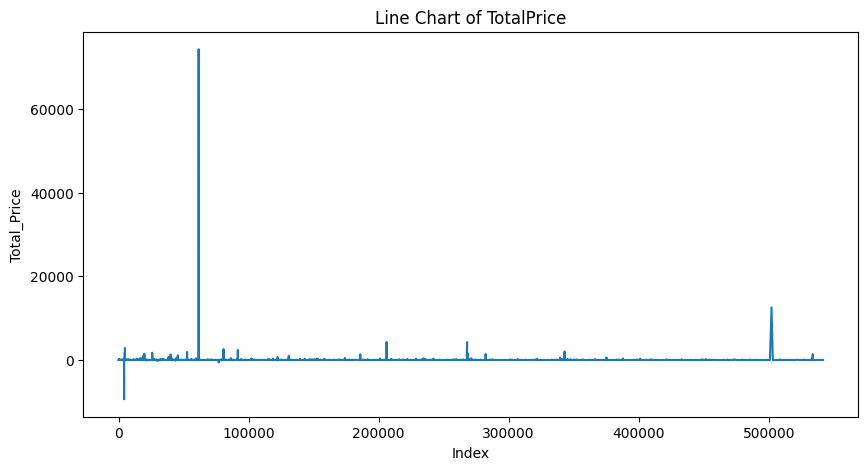

In [47]:
plt.figure(figsize=(10,5))
plt.plot(df["Total_Price"])
plt.xlabel("Index")
plt.ylabel("Total_Price")
plt.title("Line Chart of TotalPrice")
plt.show()

Bar chart

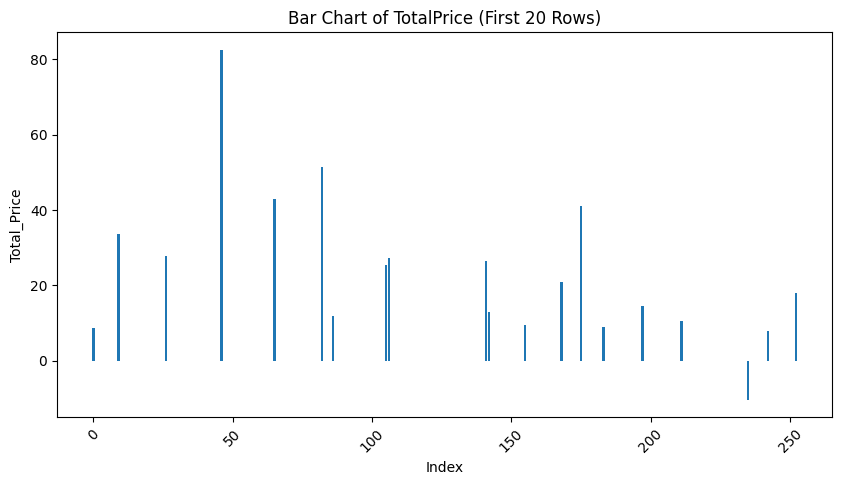

In [48]:
plt.figure(figsize=(10,5))
plt.bar(df.index[:20], df["Total_Price"][:20])
plt.xlabel("Index")
plt.ylabel("Total_Price")
plt.title("Bar Chart of TotalPrice (First 20 Rows)")
plt.xticks(rotation=45)
plt.show()

Histogram

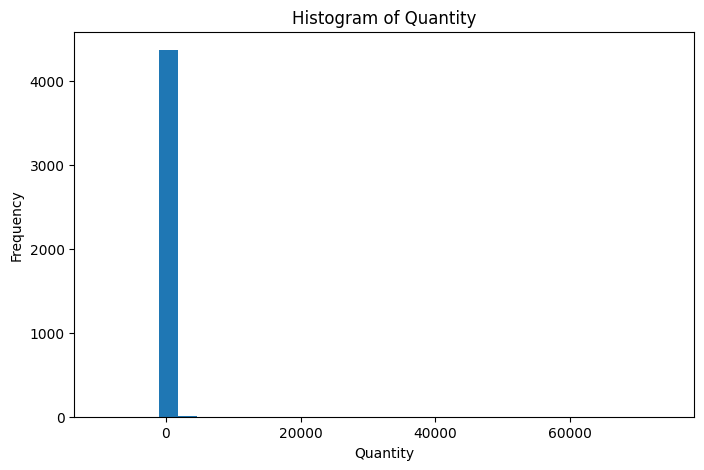

In [49]:
plt.figure(figsize=(8,5))
plt.hist(df["Quantity"], bins=30)
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.title("Histogram of Quantity")
plt.show()

Box plot

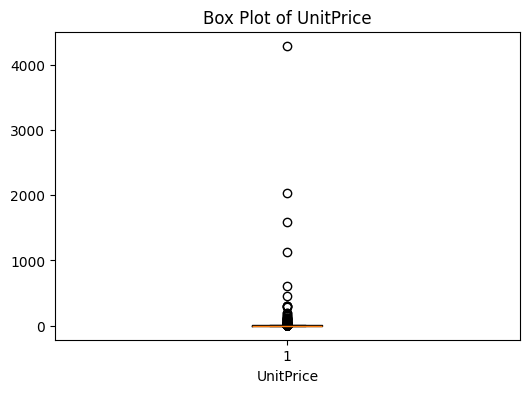

In [50]:
plt.figure(figsize=(6,4))
plt.boxplot(df["UnitPrice"])
plt.xlabel("UnitPrice")
plt.title("Box Plot of UnitPrice")
plt.show()

Seaborn

In [51]:
import seaborn as sns

Line chart

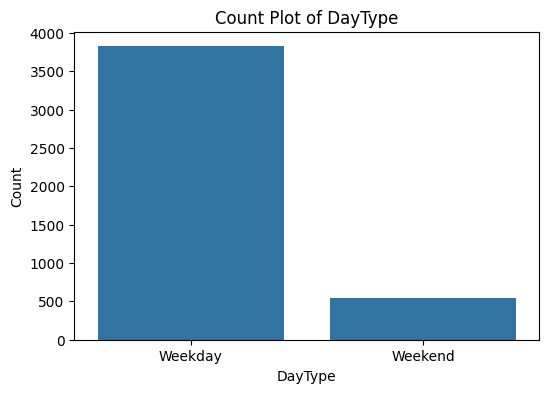

In [52]:
plt.figure(figsize=(6,4))
sns.countplot(x="DayType", data=df)
plt.xlabel("DayType")
plt.ylabel("Count")
plt.title("Count Plot of DayType")
plt.show()

Violin plot

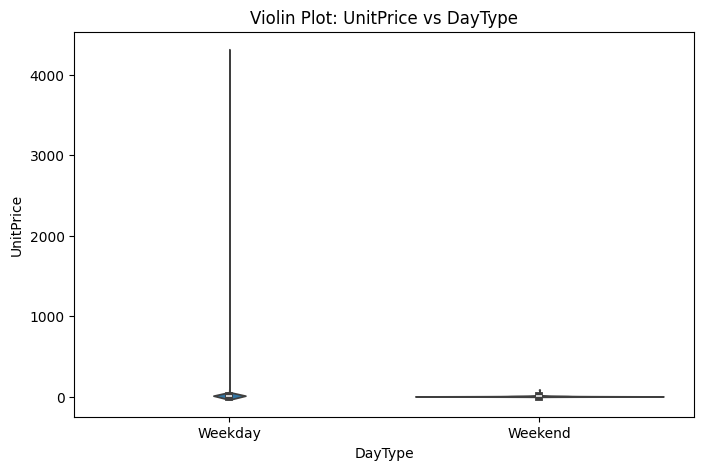

In [53]:
plt.figure(figsize=(8,5))
sns.violinplot(x="DayType", y="UnitPrice", data=df)
plt.xlabel("DayType")
plt.ylabel("UnitPrice")
plt.title("Violin Plot: UnitPrice vs DayType")
plt.show()

Heatmap

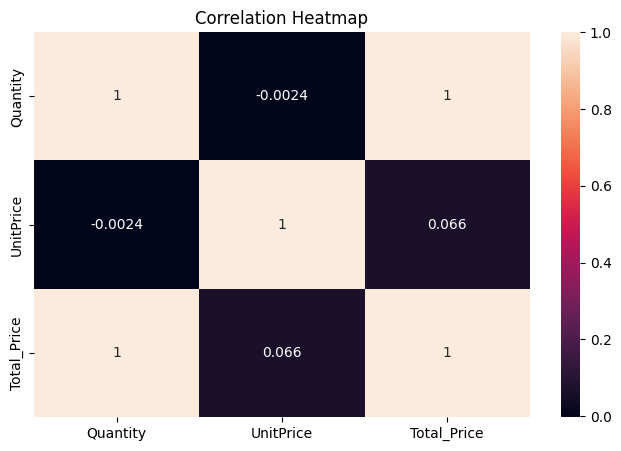

In [54]:
plt.figure(figsize=(8,5))
sns.heatmap(df[["Quantity","UnitPrice","Total_Price"]].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

Pair plot

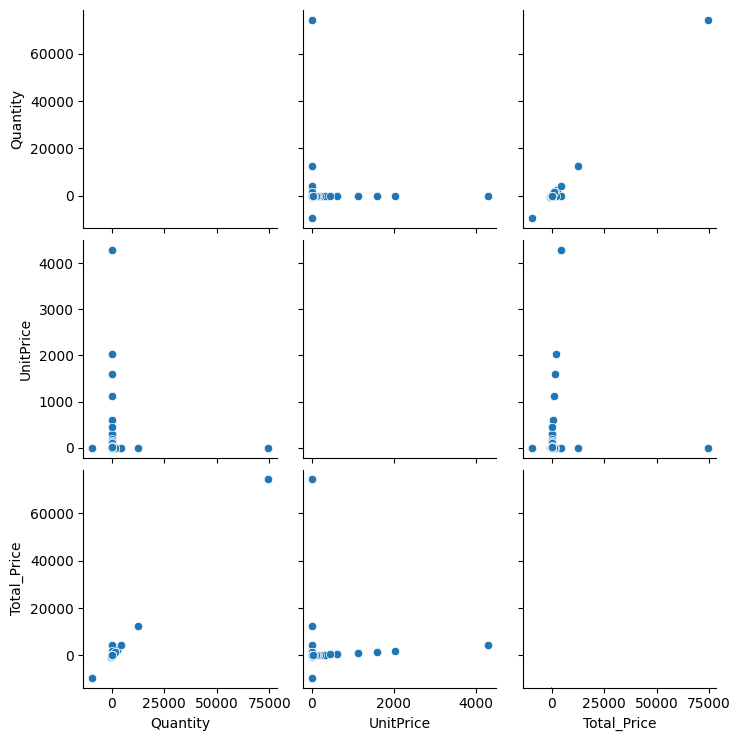

In [55]:
sns.pairplot(df[["Quantity","UnitPrice","Total_Price"]])
plt.show()

Task 8 – Business Insights

Identify:

In [58]:
df.groupby("Country")["Total_Price"].sum().sort_values(ascending=False).head(1)

,Total_Price
Country,
United Kingdom,191786.93


In [60]:
df.groupby("month")["Total_Price"].sum().sort_values(ascending=False).head(1)

,Total_Price
month,
1,84973.28


In [62]:
df.groupby("hour")["Total_Price"].sum().sort_values(ascending=False).head(1)

,Total_Price
hour,
10,94601.36


Analyze:

In [64]:
df.groupby("CustomerID")["Total_Price"].sum().sort_values(ascending=False).head(5)

,Total_Price
CustomerID,
12346.0,74216.04
13256.0,12540.00
13135.0,4300.72
17448.0,4286.63
16754.0,2880.18


In [66]:
df.groupby("Description")["Total_Price"].sum().sort_values(ascending=False).head(5)

,Total_Price
Description,
MEDIUM CERAMIC TOP STORAGE JAR,74313.08
ASSTD DESIGN 3D PAPER STICKERS,12480.85
Manual,10705.59
WORLD WAR 2 GLIDERS ASSTD DESIGNS,5953.76
SMALL POPCORN HOLDER,4677.56
